<style>
    /* page size */
    @page {
        size: A4 landscape;
        margin: 10mm;
    }
    
    /* code */
    pre, .CodeMirror-code, .jp-CodeCell .jp-InputArea-editor {
        white-space: pre-wrap !important;
        word-wrap: break-word !important;
        overflow-wrap: break-word !important;
    }
</style>

<a id="top"></a>

<hr>

<div style="border:1px solid #ddd; border-radius:12px; padding:16px 20px; background:#fafafa; margin:16px 0 24px 0;">

<h2 style="margin-top:0;">About this document</h2>

<p>
<em>This assignment submission is prepared for the UCL CASA module Data Science for Spatial Systems (CASA0006).</em><br>
<em>The notebook is self-contained and includes introduction, research questions, data handling, embedded code, visualisation, modelling, discussion and bibliography.</em><br>
<em>Word count: approximately 1,450 words.</em>
</p>

<p style="margin-bottom:0;">
<strong>Code and data:</strong> <a href="https://github.com/brotree-code/CASA0006-London-crime-and-deprivation-analysis">GitHub repository</a>
</p>

</div>

<hr>

<div style="text-align:center;">

<h1>A 2021 LSOA-based analysis of community deprivation and violence rates in London, 2024-2026</h1>

<h2><em>Community structure and recorded Violence Against the Person at small-area scale</em></h2>

<p><em>This study uses 2024-2026 monthly LSOA-level crime records from the Metropolitan Police Service, combined with Census 2021 indicators on population, household deprivation, population density, housing tenure, and 2021 LSOA geographic boundaries, to analyse spatial differences in violence rates across small areas in London and their associations with community structure.</em></p>

</div>

<hr>

<h2>Contents</h2>

<table style="width:100%; border-collapse:collapse;">
<tr>
<td style="width:33.3%; padding:6px 12px 6px 0; border:none; background:transparent;">
<a href="#intro">1.0 Introduction</a>
</td>
<td style="width:33.3%; padding:6px 12px; border:none; background:transparent;">
<a href="#lit">2.0 Literature and Research Questions</a>
</td>
<td style="width:33.3%; padding:6px 0 6px 12px; border:none; background:transparent;">
<a href="#method">3.0 Method</a>
</td>
</tr>

<tr>
<td style="padding:6px 12px 6px 0; border:none; background:transparent;">
<a href="#data">4.0 Data</a>
</td>
<td style="padding:6px 12px; border:none; background:transparent;">
<a href="#explore">5.0 Data Exploration</a>
</td>
<td style="padding:6px 0 6px 12px; border:none; background:transparent;">
<a href="#analysis">6.0 Analysis</a>
</td>
</tr>

<tr>
<td style="padding:6px 12px 6px 0; border:none; background:transparent;">
<a href="#discussion">7.0 Discussion and Conclusion</a>
</td>
<td style="padding:6px 12px; border:none; background:transparent;">
<a href="#refs">Bibliography</a>
</td>
<td style="padding:6px 0 6px 12px; border:none; background:transparent;">
<a href="#appendix">Appendix</a>
</td>
</tr>
</table>

<hr>


<a id="intro"></a>

## 1.0 | Introduction

[[ go back to the top ]](#top)
    
Crime is unevenly distributed across urban space. Social disorganisation theory links crime risk to deprivation, mobility and weakened community organisation (Shaw and McKay, 1942), while collective efficacy theory explains why local social control may reduce violence (Sampson, Raudenbush and Earls, 1997). Environmental criminology also shows that crime concentrates in small places because opportunities and routine activities vary locally (Brantingham and Brantingham, 1995; Weisburd, Groff and Yang, 2012).

This study asks whether London LSOA violence rates are associated with household deprivation, density and housing tenure. Rates per 1,000 residents are used for exploration, while the count model includes a population offset.


<a id="lit"></a>

## 2.0 | Literature and Research Questions

[[ go back to the top ]](#top)
    
**RQ1:** How is the 2024-2026 violence rate spatially distributed across London LSOAs?

**RQ2:** After accounting for population size, how are household deprivation, population density and housing tenure associated with violence counts?

**RQ3:** Can London LSOAs be grouped into exploratory profiles with different violence rates and community structures?

The expectation is that areas with greater deprivation, more renting and larger non-household populations may record higher violence rates. This is an explanatory spatial association study, not a causal identification design.


<a id="method"></a>

## 3.0 | Method

[[ go back to the top ]](#top)
    
The workflow has four stages. First, MPS monthly records are aggregated into 24-month Violence Against the Person counts at 2021 LSOA level. Second, these counts are joined to Census 2021 population, deprivation, density and tenure variables plus ONS 2021 LSOA boundaries. Third, annualised rates per 1,000 residents are used for exploratory comparison and polygon mapping. Fourth, the main inference uses a count model rather than an ordinary linear model on rates.

The model outcome is the 24-month violence count. `log(population_2021)` is included as an offset, so coefficients describe differences in expected counts after normalising for residential population size. Predictors are standardised before modelling, allowing incidence rate ratios (IRRs) to be compared as the effect of a one standard deviation increase. A Poisson GLM is fitted first to test overdispersion; because crime counts are highly overdispersed, the main specification is Negative Binomial. K-means is then used only as an exploratory profiling method, not as evidence of causal neighbourhood types.


In [1]:
from pathlib import Path
import json
import math
import warnings
import zipfile
import requests

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

from IPython.display import display
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import statsmodels.api as sm
from statsmodels.discrete.discrete_model import NegativeBinomial

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.dpi"] = 220
plt.rcParams["font.family"] = "DejaVu Sans"

BASE = Path.cwd()
if not (BASE / "data").exists() and (BASE / "london_crime_deprivation_cn" / "data").exists():
    BASE = BASE / "london_crime_deprivation_cn"

DATA = BASE / "data"
OUT = BASE / "outputs"
OUT.mkdir(exist_ok=True)

print("Project folder:", BASE)
print("Data files:", len(list(DATA.glob("*"))))


Project folder: E:\DS\final2\london_crime_deprivation
Data files: 14


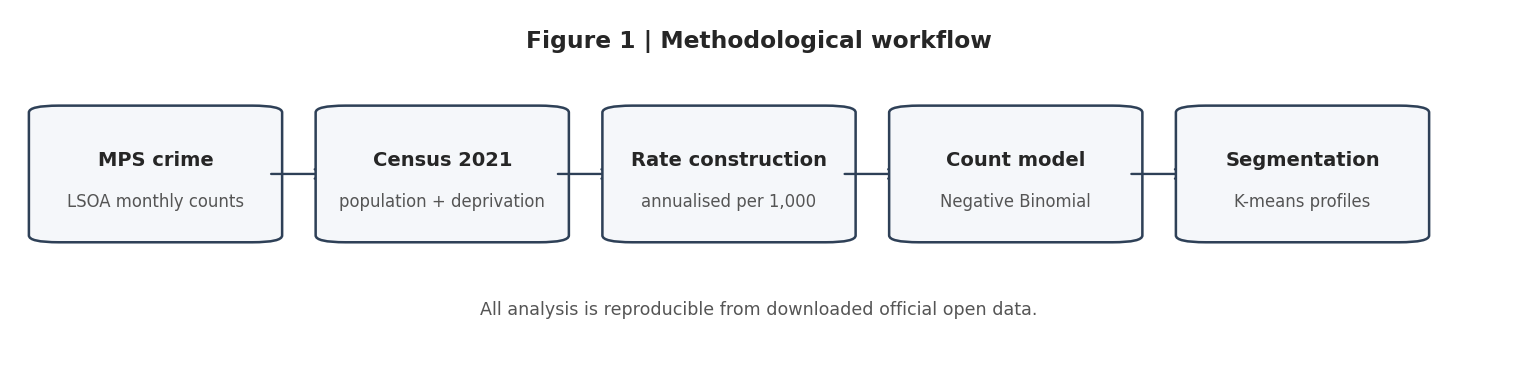

In [2]:
# Create a simple methodology flow image used above.
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(11, 2.8))
ax.set_axis_off()

steps = [
    ("MPS crime", "LSOA monthly counts"),
    ("Census 2021", "population + deprivation"),
    ("Rate construction", "annualised per 1,000"),
    ("Count model", "Negative Binomial"),
    ("Segmentation", "K-means profiles"),
]

box_width = 0.13
xs = np.linspace(0.03, 0.80, len(steps))
for i, (title, subtitle) in enumerate(steps):
    box = FancyBboxPatch((xs[i], 0.35), box_width, 0.36,
                         boxstyle="round,pad=0.02,rounding_size=0.02",
                         linewidth=1.3, edgecolor="#2E4057", facecolor="#F5F7FA",
                         transform=ax.transAxes)
    ax.add_patch(box)
    ax.text(xs[i]+0.065, 0.57, title, ha="center", va="center",
            fontsize=10, weight="bold", transform=ax.transAxes)
    ax.text(xs[i]+0.065, 0.45, subtitle, ha="center", va="center",
            fontsize=8.5, color="#555", transform=ax.transAxes)
    if i < len(steps)-1:
        arrow = FancyArrowPatch((xs[i]+box_width+0.01, 0.53), (xs[i+1]-0.01, 0.53),
                                arrowstyle="->", mutation_scale=12,
                                linewidth=1.2, color="#2E4057",
                                transform=ax.transAxes)
        ax.add_patch(arrow)

ax.text(0.5, 0.12, "All analysis is reproducible from downloaded official open data.",
        ha="center", fontsize=9, color="#555", transform=ax.transAxes)
ax.text(0.5, 0.9, "Figure 1 | Methodological workflow",
        ha="center", fontsize=12, weight="bold", transform=ax.transAxes)
fig.tight_layout()
fig.savefig(OUT / "fig_00_method_flow.png", bbox_inches="tight")
plt.show()


**Figure 1 | Methodological workflow.** The figure summarises the route from official MPS and Census data to LSOA aggregation, population standardisation, count modelling and exploratory clustering.


<a id="data"></a>

## 4.0 | Data

[[ go back to the top ]](#top)

The main dataset is the MPS LSOA-level crime record from the London Datastore. It reports offences by category and month. This study uses `202404` to `202603`, giving a 24-month window and excluding `202403` to avoid a 25-month period.

Auxiliary data are Nomis/ONS Census 2021 bulk tables: TS001 population, TS006 density, TS011 household deprivation and TS054 housing tenure. Coordinates, area and polygon geometry come from ONS Open Geography 2021 LSOA boundaries. All source links and file-size records are documented in `data_sources.json` for reproducibility.

IMD 2019 was downloaded but excluded from the main model because it uses 2011 LSOA boundaries, while recent MPS crime data uses 2021 LSOA codes. Census 2021 household deprivation is therefore used to maintain geographic consistency.

Data quality checks are built into the notebook. Each input table is checked for unique LSOA codes before merging, and the final analytical table is asserted to contain no duplicated LSOA rows. The completed merge produces **4,988** analytical LSOAs, with **0** missing values in the model variables and full polygon matches for the mapped LSOAs. This makes the spatial and statistical units consistent across the analysis.

Although all main variables use 2021 LSOA geography, results remain sensitive to spatial aggregation. They should be interpreted as area-level patterns, not individual-level risk, with MAUP as a limitation (Openshaw, 1984).


In [3]:
source_manifest = json.loads((BASE / "data_sources.json").read_text(encoding="utf-8"))
pd.DataFrame(source_manifest).T[["url", "bytes"]]


,url,bytes
mps_lsoa_crime_recent_24m.csv,https://data.london.gov.uk/download/exy3m/nmy/...,13534958
id2019_london.xlsx,https://data.london.gov.uk/download/2l15g/9ee0...,3926592
census2021_ts001.zip,https://www.nomisweb.co.uk/output/census/2021/...,1870128
lsoa2021_boundaries_attributes.csv,https://open-geography-portalx-ons.hub.arcgis....,4953303
census2021_ts006.zip,https://www.nomisweb.co.uk/output/census/2021/...,1849811
census2021_ts011.zip,https://www.nomisweb.co.uk/output/census/2021/...,2765908
census2021_ts054.zip,https://www.nomisweb.co.uk/output/census/2021/...,4074446
lsoa2021_boundaries_bgc_shapefile.zip,https://open-geography-portalx-ons.hub.arcgis....,17350732


In [4]:
crime = pd.read_csv(DATA / "mps_lsoa_crime_recent_24m.csv")
month_cols = [c for c in crime.columns if c.isdigit()]
analysis_months = [m for m in month_cols if "202404" <= m <= "202603"]

print("Rows:", len(crime))
print("Unique LSOAs:", crime["LSOA Code"].nunique())
print("Months in raw file:", month_cols[0], "to", month_cols[-1], "|", len(month_cols), "columns")
print("Months used:", analysis_months[0], "to", analysis_months[-1], "|", len(analysis_months), "months")
display(crime[
    [
        "LSOA Code",
        "LSOA Name",
        "Borough",
        "Major Category",
        "Minor Category",
        "202404",
        "202410",
        "202504",
        "202510",
        "202603"
    ]
].head())


Rows: 105646
Unique LSOAs: 4988
Months in raw file: 202403 to 202603 | 25 columns
Months used: 202404 to 202603 | 24 months


,LSOA Code,LSOA Name,Borough,Major Category,Minor Category,202404,202410,202504,202510,202603
0,E01000006,Barking and Dagenham 016A,E09000002,ARSON AND CRIMINAL DAMAGE,ARSON,0,0,0,0,0
1,E01000006,Barking and Dagenham 016A,E09000002,ARSON AND CRIMINAL DAMAGE,CRIMINAL DAMAGE,0,0,0,0,0
2,E01000006,Barking and Dagenham 016A,E09000002,BURGLARY,RES BURGLARY OF A HOME,0,0,1,0,0
3,E01000006,Barking and Dagenham 016A,E09000002,BURGLARY,RES BURGLARY OF UNCONNECTED BUILDING,0,0,0,0,0
4,E01000006,Barking and Dagenham 016A,E09000002,DRUG OFFENCES,POSSESSION OF DRUGS,0,0,0,1,0


In [5]:
major_by_month = crime.groupby("Major Category")[analysis_months].sum().T
major_by_month.index = pd.to_datetime(major_by_month.index, format="%Y%m")

violent = crime[crime["Major Category"].str.upper().eq("VIOLENCE AGAINST THE PERSON")].copy()
violence = violent.groupby(["LSOA Code", "LSOA Name", "Borough"], as_index=False)[analysis_months].sum()
violence["violence_count_24m"] = violence[analysis_months].sum(axis=1)
violence = violence[["LSOA Code", "LSOA Name", "Borough", "violence_count_24m"]]

display(violence.head())
print("Total violence against the person offences, 24 months:", f"{violence['violence_count_24m'].sum():,}")


,LSOA Code,LSOA Name,Borough,violence_count_24m
0,E01000006,Barking and Dagenham 016A,E09000002,62
1,E01000007,Barking and Dagenham 015A,E09000002,385
2,E01000008,Barking and Dagenham 015B,E09000002,114
3,E01000009,Barking and Dagenham 016B,E09000002,164
4,E01000011,Barking and Dagenham 016C,E09000002,120


Total violence against the person offences, 24 months: 467,771


In [6]:
pop = pd.read_csv(DATA / "census2021_ts001" / "census2021-ts001-lsoa.csv")
pop = pop.rename(columns={
    "geography code": "lsoa21cd",
    "geography": "lsoa21nm",
    "Residence type: Total; measures: Value": "population_2021",
    "Residence type: Lives in a household; measures: Value": "household_population_2021",
    "Residence type: Lives in a communal establishment; measures: Value": "communal_population_2021",
})[["lsoa21cd", "lsoa21nm", "population_2021", "household_population_2021", "communal_population_2021"]]
pop["communal_establishment_pct"] = 100 * pop["communal_population_2021"] / pop["population_2021"]

hh = pd.read_csv(DATA / "census2021_ts011" / "census2021-ts011-lsoa.csv")
hh = hh.rename(columns={
    "geography code": "lsoa21cd",
    "Household deprivation: Total: All households; measures: Value": "households_total",
    "Household deprivation: Household is not deprived in any dimension; measures: Value": "hh_not_deprived",
    "Household deprivation: Household is deprived in one dimension; measures: Value": "hh_deprived_1",
    "Household deprivation: Household is deprived in two dimensions; measures: Value": "hh_deprived_2",
    "Household deprivation: Household is deprived in three dimensions; measures: Value": "hh_deprived_3",
    "Household deprivation: Household is deprived in four dimensions; measures: Value": "hh_deprived_4",
})[["lsoa21cd", "households_total", "hh_not_deprived", "hh_deprived_1", "hh_deprived_2", "hh_deprived_3", "hh_deprived_4"]]
hh["deprived_1plus_pct"] = 100 * (hh["households_total"] - hh["hh_not_deprived"]) / hh["households_total"]
hh["deprived_2plus_pct"] = 100 * (hh["hh_deprived_2"] + hh["hh_deprived_3"] + hh["hh_deprived_4"]) / hh["households_total"]
hh["deprived_3plus_pct"] = 100 * (hh["hh_deprived_3"] + hh["hh_deprived_4"]) / hh["households_total"]

pdens = pd.read_csv(DATA / "census2021_ts006" / "census2021-ts006-lsoa.csv")
pdens = pdens.rename(columns={
    "geography code": "lsoa21cd",
    "Population Density: Persons per square kilometre; measures: Value": "population_density_km2",
})[["lsoa21cd", "population_density_km2"]]
pdens["log_population_density"] = np.log1p(pdens["population_density_km2"])

tenure = pd.read_csv(DATA / "census2021_ts054" / "census2021-ts054-lsoa.csv")
tenure = tenure.rename(columns={
    "geography code": "lsoa21cd",
    "Tenure of household: Total: All households": "tenure_households_total",
    "Tenure of household: Owned": "owned",
    "Tenure of household: Social rented": "social_rented",
    "Tenure of household: Private rented": "private_rented",
})[["lsoa21cd", "tenure_households_total", "owned", "social_rented", "private_rented"]]
tenure["owned_pct"] = 100 * tenure["owned"] / tenure["tenure_households_total"]
tenure["social_rented_pct"] = 100 * tenure["social_rented"] / tenure["tenure_households_total"]
tenure["private_rented_pct"] = 100 * tenure["private_rented"] / tenure["tenure_households_total"]

attrs = pd.read_csv(DATA / "lsoa2021_boundaries_attributes.csv")
attrs = attrs.rename(columns={
    "LSOA21CD": "lsoa21cd",
    "LSOA21NM": "lsoa21nm_boundary",
    "BNG_E": "bng_e",
    "BNG_N": "bng_n",
    "LAT": "lat",
    "LONG": "lon",
    "Shape__Area": "area_m2",
})[["lsoa21cd", "lsoa21nm_boundary", "bng_e", "bng_n", "lat", "lon", "area_m2"]]
attrs["area_km2"] = attrs["area_m2"] / 1_000_000

# Polygon boundary data for the choropleth map.
boundary_url = "https://open-geography-portalx-ons.hub.arcgis.com/api/download/v1/items/68515293204e43ca8ab56fa13ae8a547/shapefile-layers=0"
boundary_zip = DATA / "lsoa2021_boundaries_bgc_shapefile.zip"
boundary_dir = DATA / "lsoa2021_boundaries_bgc_shapefile"
shp_path = boundary_dir / "LSOA_2021_EW_BGC_V5.shp"

if not shp_path.exists():
    boundary_dir.mkdir(exist_ok=True)
    if not boundary_zip.exists():
        with requests.get(boundary_url, stream=True, timeout=120) as r:
            r.raise_for_status()
            with open(boundary_zip, "wb") as f:
                for chunk in r.iter_content(1024 * 1024):
                    if chunk:
                        f.write(chunk)
    with zipfile.ZipFile(boundary_zip) as z:
        z.extractall(boundary_dir)


In [7]:
def check_unique(df, key, name):
    duplicated = df[key].duplicated().sum()
    print(f"{name}: {df[key].nunique():,} unique {key}; duplicated rows = {duplicated:,}")
    assert duplicated == 0, f"{name} has duplicated {key} values"

check_unique(violence, "LSOA Code", "Violence data")
check_unique(pop, "lsoa21cd", "Census population")
check_unique(hh, "lsoa21cd", "Household deprivation")
check_unique(pdens, "lsoa21cd", "Population density")
check_unique(tenure, "lsoa21cd", "Housing tenure")
check_unique(attrs, "lsoa21cd", "LSOA attribute table")

analysis = (
    violence.rename(columns={"LSOA Code": "lsoa21cd", "LSOA Name": "lsoa_name", "Borough": "borough_code"})
    .merge(pop, on="lsoa21cd", how="left")
    .merge(hh, on="lsoa21cd", how="left")
    .merge(pdens, on="lsoa21cd", how="left")
    .merge(tenure, on="lsoa21cd", how="left")
    .merge(attrs, on="lsoa21cd", how="left")
)

analysis["violence_rate_per_1000_24m"] = 1000 * analysis["violence_count_24m"] / analysis["population_2021"]
analysis["violence_rate_per_1000_annual"] = analysis["violence_rate_per_1000_24m"] / 2
analysis["borough_name"] = analysis["lsoa_name"].str.replace(r" \d{3}[A-Z]$", "", regex=True)

needed = [
    "violence_count_24m", "population_2021", "deprived_2plus_pct",
    "population_density_km2", "log_population_density", "social_rented_pct",
    "private_rented_pct", "communal_establishment_pct", "bng_e", "bng_n"
]
analysis = analysis.dropna(subset=needed).copy()
analysis = analysis[analysis["population_2021"] > 0].copy()
assert analysis["lsoa21cd"].duplicated().sum() == 0, "Duplicated LSOAs were introduced during merging"
analysis.to_csv(DATA / "processed_lsoa_analysis.csv", index=False)

print("Final analytical LSOAs:", len(analysis))
print("Population covered:", f"{analysis['population_2021'].sum():,}")
print("Missing values after merge:", int(analysis[needed].isna().sum().sum()))
print("Duplicated LSOA rows after merge:", int(analysis["lsoa21cd"].duplicated().sum()))
analysis_preview = analysis[
    [
        "lsoa21cd",
        "borough_name",
        "violence_count_24m",
        "population_2021",
        "violence_rate_per_1000_annual",
        "deprived_2plus_pct",
        "log_population_density",
        "social_rented_pct",
        "private_rented_pct",
        "communal_establishment_pct"
    ]
].head().rename(columns={
    "lsoa21cd": "LSOA",
    "borough_name": "Borough",
    "violence_count_24m": "Violence",
    "population_2021": "Pop",
    "violence_rate_per_1000_annual": "Rate",
    "deprived_2plus_pct": "Deprived2+",
    "log_population_density": "LogDensity",
    "social_rented_pct": "SocialRent",
    "private_rented_pct": "PrivateRent",
    "communal_establishment_pct": "Communal"
})

display(analysis_preview)


Violence data: 4,988 unique LSOA Code; duplicated rows = 0
Census population: 35,672 unique lsoa21cd; duplicated rows = 0
Household deprivation: 35,672 unique lsoa21cd; duplicated rows = 0
Population density: 35,672 unique lsoa21cd; duplicated rows = 0
Housing tenure: 35,672 unique lsoa21cd; duplicated rows = 0
LSOA attribute table: 35,672 unique lsoa21cd; duplicated rows = 0


Final analytical LSOAs: 4988
Population covered: 8,791,193
Missing values after merge: 0
Duplicated LSOA rows after merge: 0


,LSOA,Borough,Violence,Pop,Rate,Deprived2+,LogDensity,SocialRent,PrivateRent,Communal
0,E01000006,Barking and Dagenham,62,1845,16.802168,19.675090,9.440364,3.978300,46.473779,0.000000
1,E01000007,Barking and Dagenham,385,2908,66.196699,20.269134,9.584728,37.983193,35.042017,0.000000
2,E01000008,Barking and Dagenham,114,1795,31.754875,33.515483,9.134830,56.569343,26.824818,0.000000
3,E01000009,Barking and Dagenham,164,1804,45.454545,28.286190,9.554341,19.397993,46.822742,1.108647
4,E01000011,Barking and Dagenham,120,1701,35.273369,23.678647,9.828257,5.919662,52.219873,0.646678


| Variable | Short name | Type | Description and use |
|---|---|---|---|
| `violence_count_24m` | Violence | Count | Violence records over 24 months. Used as the Negative Binomial outcome. |
| `violence_rate_per_1000_annual` | Rate | Rate | Annualised violence rate per 1,000 residents. Used for mapping and descriptive analysis. |
| `population_2021` | Pop | Numeric | Census 2021 population. Used as the population offset. |
| `deprived_2plus_pct` | Deprived2+ | Numeric | Share of households deprived in two or more dimensions. Used as the deprivation indicator. |
| `log_population_density` | LogDensity | Numeric | Log-transformed population density. Used as the density control. |
| `social_rented_pct` | SocialRent | Numeric | Share of socially rented households. Used as a housing tenure variable. |
| `private_rented_pct` | PrivateRent | Numeric | Share of privately rented households. Used as a housing tenure variable. |
| `communal_establishment_pct` | Communal | Numeric | Share of residents living in communal establishments. Used as a non-household population control. |

<a id="explore"></a>

## 5.0 | Data Exploration

[[ go back to the top ]](#top)

After cleaning and merging, the analytical sample contains **4,988** LSOAs and covers approximately **8,791,193** residents. There were **467,771** Violence Against the Person records across the 24-month window. The mean annualised violence rate is **26.14** per 1,000 residents, while the median is **21.62**, indicating a right-skewed distribution in which a small number of central or highly active LSOAs raise the average. This is why the map uses a capped colour scale for display while the model retains the original uncapped count outcome.


In [8]:
summary_cols = [
    "violence_count_24m", "violence_rate_per_1000_annual", "population_2021",
    "deprived_2plus_pct", "population_density_km2", "social_rented_pct",
    "private_rented_pct", "communal_establishment_pct"
]
analysis[summary_cols].describe().T.round(2)


,count,mean,std,min,25%,50%,75%,max
violence_count_24m,4988.0,93.78,94.92,2.00,47.00,75.00,111.00,2313.00
violence_rate_per_1000_annual,4988.0,26.14,25.54,0.64,14.28,21.62,29.91,683.91
population_2021,4988.0,1762.47,319.80,1002.00,1548.00,1716.50,1930.00,4279.00
deprived_2plus_pct,4988.0,19.06,7.96,2.13,12.78,18.29,24.89,48.00
population_density_km2,4988.0,10405.56,7124.01,119.90,5567.65,9012.60,13694.18,115567.00
social_rented_pct,4988.0,22.59,18.63,0.00,7.05,17.32,34.34,92.02
private_rented_pct,4988.0,29.06,13.67,2.63,18.47,27.93,38.10,86.09
communal_establishment_pct,4988.0,1.07,3.68,0.00,0.00,0.00,0.44,54.14


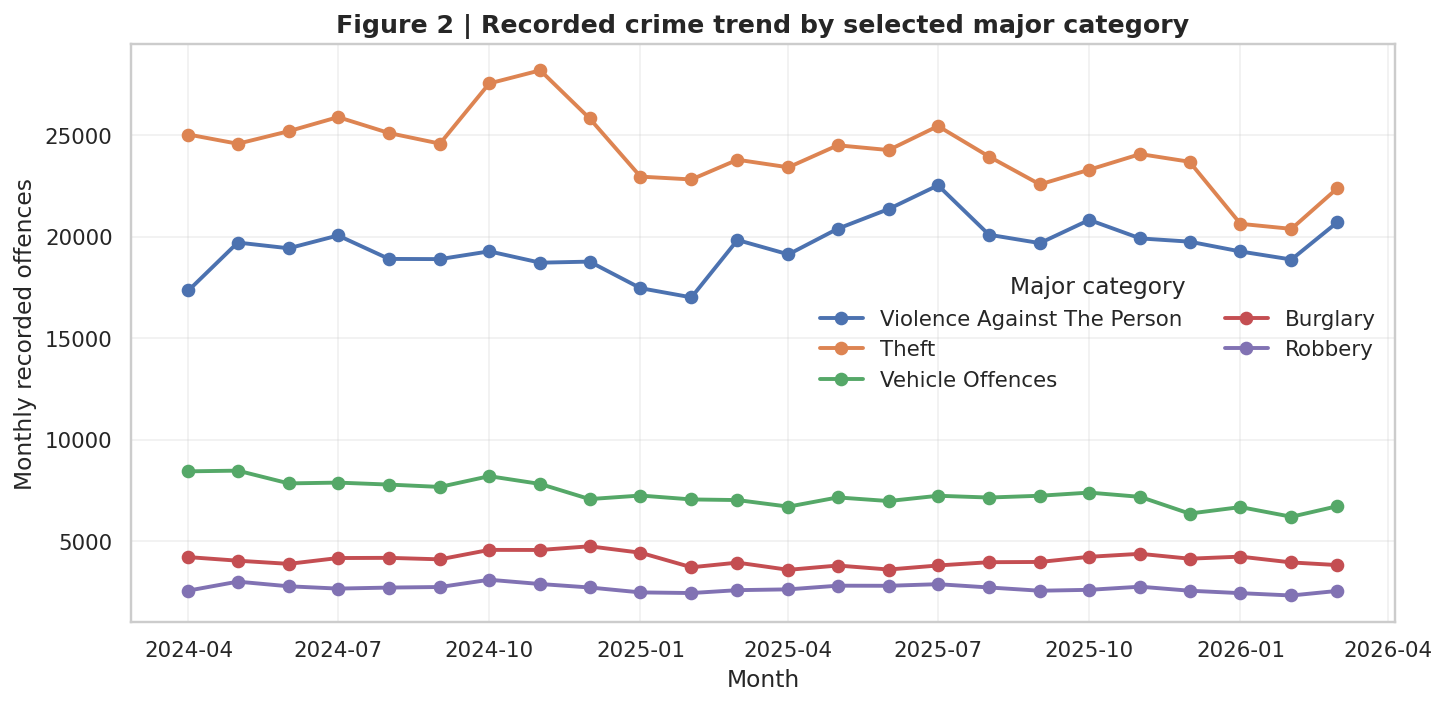

In [9]:
fig, ax = plt.subplots(figsize=(10.5, 5.2))
plot_cats = ["VIOLENCE AGAINST THE PERSON", "THEFT", "VEHICLE OFFENCES", "BURGLARY", "ROBBERY"]
for cat in plot_cats:
    if cat in major_by_month.columns:
        ax.plot(major_by_month.index, major_by_month[cat], marker="o", linewidth=2, label=cat.title())
ax.set_title("Figure 2 | Recorded crime trend by selected major category", fontsize=13, weight="bold")
ax.set_ylabel("Monthly recorded offences")
ax.set_xlabel("Month")
ax.legend(frameon=False, ncol=2, title="Major category")
ax.grid(True, alpha=.25)
fig.tight_layout()
fig.savefig(OUT / "fig_01_monthly_trend.png")
plt.show()


**Figure 2 | Monthly trend in major crime categories.** The figure compares the five largest recorded crime categories and shows the scale and temporal variation of the selected violence outcome.


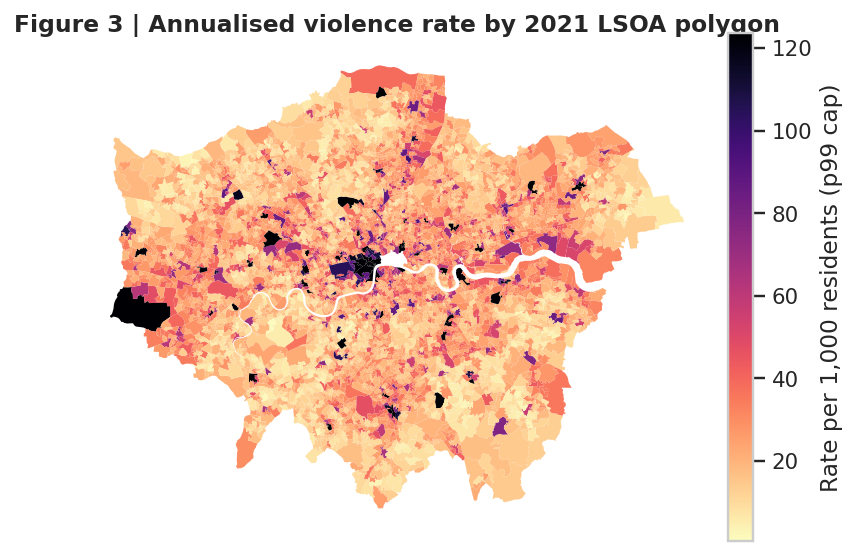

In [10]:
fig, ax = plt.subplots(figsize=(5.9, 5.4))

lsoa_gdf = gpd.read_file(shp_path, columns=["LSOA21CD", "geometry"]).rename(columns={"LSOA21CD": "lsoa21cd"})
map_gdf = lsoa_gdf.merge(
    analysis[["lsoa21cd", "violence_rate_per_1000_annual"]],
    on="lsoa21cd",
    how="inner",
    validate="one_to_one",
)
assert len(map_gdf) == len(analysis), "Not all analytical LSOAs have polygon geometry"

rate_p99 = analysis["violence_rate_per_1000_annual"].quantile(0.99)
map_gdf["violence_rate_p99_cap"] = map_gdf["violence_rate_per_1000_annual"].clip(upper=rate_p99)

map_gdf.plot(
    column="violence_rate_p99_cap",
    ax=ax,
    cmap="magma_r",
    linewidth=0,
    legend=True,
    legend_kwds={"label": "Rate per 1,000 residents (p99 cap)", "shrink": 0.72, "pad": 0.02},
)
ax.set_aspect("equal")
ax.set_axis_off()
ax.set_title("Figure 3 | Annualised violence rate by 2021 LSOA polygon", fontsize=12, weight="bold")
fig.tight_layout()
fig.savefig(OUT / "fig_02_spatial_rate_map.png", dpi=180, bbox_inches="tight")
plt.show()



**Figure 3 | Annualised violence rate by 2021 LSOA polygon.** The map shows annualised Violence Against the Person rates per 1,000 residents for all **4,988** analytical LSOAs. The colour scale is capped at the 99th percentile for visualisation only; modelling uses uncapped values.


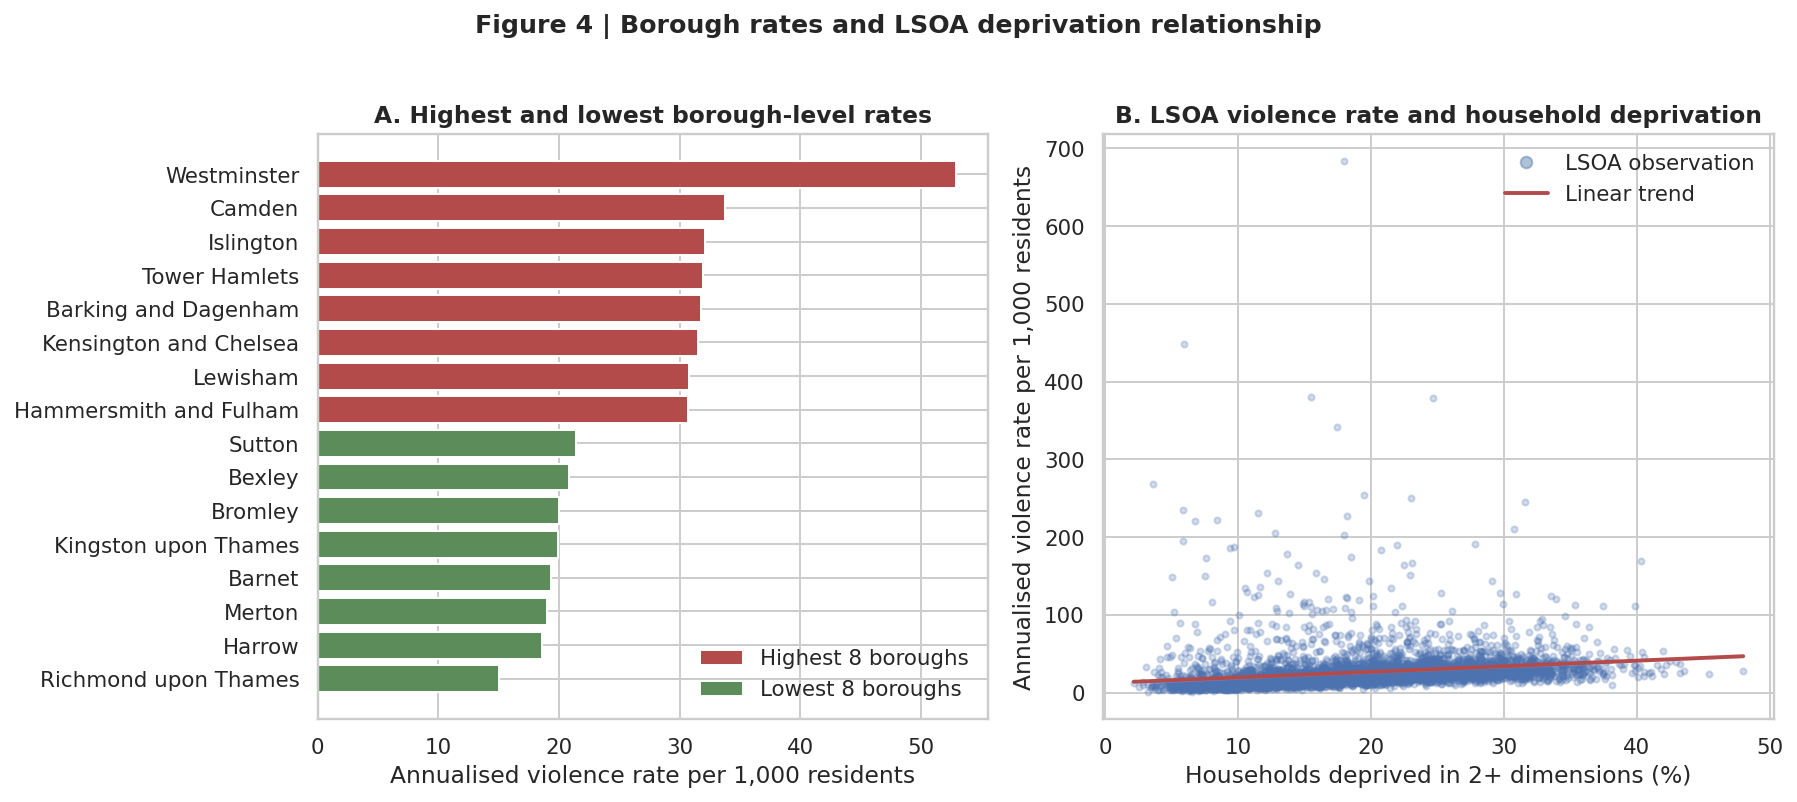

Highest borough: Westminster 52.91
Lowest borough: Richmond upon Thames 14.98
LSOA correlation between deprivation and violence rate: 0.223


In [11]:
borough = (
    analysis.groupby(["borough_code", "borough_name"], as_index=False)
    .agg(
        violence_count_24m=("violence_count_24m", "sum"),
        population_2021=("population_2021", "sum"),
        deprived_2plus_pct=("deprived_2plus_pct", "mean"),
        lsoa_n=("lsoa21cd", "nunique"),
    )
)
borough["violence_rate_per_1000_annual"] = 1000 * borough["violence_count_24m"] / borough["population_2021"] / 2
borough = borough.sort_values("violence_rate_per_1000_annual", ascending=False)
borough.to_csv(OUT / "borough_summary.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.6))
top_bottom = pd.concat([borough.head(8), borough.tail(8)]).drop_duplicates()
top_bottom = top_bottom.sort_values("violence_rate_per_1000_annual")
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

highest_boroughs = set(borough.head(8)["borough_code"])
lowest_boroughs = set(borough.tail(8)["borough_code"])
top_bottom["rate_group"] = np.where(
    top_bottom["borough_code"].isin(highest_boroughs), "Highest 8 boroughs", "Lowest 8 boroughs"
)
bar_palette = {"Highest 8 boroughs": "#B44B4B", "Lowest 8 boroughs": "#5B8C5A"}
axes[0].barh(
    top_bottom["borough_name"],
    top_bottom["violence_rate_per_1000_annual"],
    color=top_bottom["rate_group"].map(bar_palette),
)
axes[0].set_xlabel("Annualised violence rate per 1,000 residents")
axes[0].set_title("A. Highest and lowest borough-level rates", weight="bold")
axes[0].legend(
    handles=[Patch(facecolor=bar_palette[k], label=k) for k in ["Highest 8 boroughs", "Lowest 8 boroughs"]],
    frameon=False,
    loc="lower right",
)
sns.regplot(
    data=analysis, x="deprived_2plus_pct", y="violence_rate_per_1000_annual",
    scatter_kws={"s": 10, "alpha": 0.25},
    line_kws={"color": "#B44B4B", "lw": 2},
    ax=axes[1],
)
axes[1].set_xlabel("Households deprived in 2+ dimensions (%)")
axes[1].set_ylabel("Annualised violence rate per 1,000 residents")
axes[1].set_title("B. LSOA violence rate and household deprivation", weight="bold")
axes[1].legend(
    handles=[
        Line2D([0], [0], marker="o", linestyle="", color="#4C78A8", alpha=0.45, label="LSOA observation"),
        Line2D([0], [0], color="#B44B4B", lw=2, label="Linear trend"),
    ],
    frameon=False,
    loc="upper right",
)
fig.suptitle("Figure 4 | Borough rates and LSOA deprivation relationship", fontsize=13, weight="bold", y=1.02)
fig.tight_layout()
fig.savefig(OUT / "fig_03_borough_and_deprivation.png")
plt.show()

print("Highest borough:", borough.iloc[0]["borough_name"], round(borough.iloc[0]["violence_rate_per_1000_annual"], 2))
print("Lowest borough:", borough.iloc[-1]["borough_name"], round(borough.iloc[-1]["violence_rate_per_1000_annual"], 2))
print("LSOA correlation between deprivation and violence rate:",
      round(analysis[["deprived_2plus_pct", "violence_rate_per_1000_annual"]].corr().iloc[0, 1], 3))


**Figure 4 | Borough rates and deprivation association.** The left panel compares borough extremes; the right panel shows a positive but limited LSOA relationship between two-or-more-dimensional household deprivation and annualised violence rate.


The highest borough-level annualised violence rate is in **Westminster** (**52.91** per 1,000 residents per year); the lowest is in **Richmond upon Thames** (**14.98**). The LSOA-level correlation between household deprivation and violence rate is **0.223**, positive but modest. This suggests deprivation matters, but it does not by itself explain the geography of recorded violence.

Borough differences should not be read only as resident risk. Central rates may reflect administration, policing and reporting, night-time economy, transport hubs, visitors, commuters and central activity zones. The later borough fixed-effects check therefore tests whether the main associations persist after absorbing broad borough-level context.


<a id="analysis"></a>

## 6.0 | Analysis

[[ go back to the top ]](#top)

Crime counts are non-negative integers and LSOAs have different population sizes, so the model uses `log(population_2021)` as an offset. A Poisson GLM is checked for overdispersion; if Pearson chi-square divided by degrees of freedom is far above 1, Negative Binomial is preferred.


In [12]:
model_vars = [
    "deprived_2plus_pct", "log_population_density",
    "social_rented_pct", "private_rented_pct", "communal_establishment_pct"
]
label_map = {
    "deprived_2plus_pct_z": "Deprived >=2 dimensions",
    "log_population_density_z": "Log population density",
    "social_rented_pct_z": "Social rented share",
    "private_rented_pct_z": "Private rented share",
    "communal_establishment_pct_z": "Communal establishment share",
}

X = analysis[model_vars].copy()
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=[v + "_z" for v in model_vars], index=analysis.index)
X_model = sm.add_constant(X_scaled)
y = analysis["violence_count_24m"]
offset = np.log(analysis["population_2021"])

poisson = sm.GLM(y, X_model, family=sm.families.Poisson(), offset=offset).fit(cov_type="HC0")
overdispersion = poisson.pearson_chi2 / poisson.df_resid
print("Poisson overdispersion ratio:", round(overdispersion, 2))

nb_model = NegativeBinomial(y, X_model, loglike_method="nb2", offset=offset)
nb_res = nb_model.fit(disp=False, maxiter=200)
print(nb_res.summary())

null_nb = NegativeBinomial(y, np.ones((len(y), 1)), loglike_method="nb2", offset=offset).fit(disp=False, maxiter=200)
nb_pseudo_r2 = 1 - nb_res.llf / null_nb.llf
print("McFadden pseudo R2:", round(nb_pseudo_r2, 3))


Poisson overdispersion ratio: 37.49
                     NegativeBinomial Regression Results                      
Dep. Variable:     violence_count_24m   No. Observations:                 4988
Model:               NegativeBinomial   Df Residuals:                     4982
Method:                           MLE   Df Model:                            5
Date:                Sun, 03 May 2026   Pseudo R-squ.:                 0.06694
Time:                        23:37:37   Log-Likelihood:                -24845.
converged:                       True   LL-Null:                       -26628.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                           -3.0614      0.007   -461.543      0.000      -3.074      -3.048
deprived_2plus_pct_z             0.1514  

,label,irr,irr_low,irr_high,pvalue
1,Deprived >=2 dimensions,1.164,1.141,1.187,0.0
2,Log population density,0.774,0.762,0.787,0.0
3,Social rented share,1.375,1.346,1.405,0.0
4,Private rented share,1.488,1.466,1.510,0.0
5,Communal establishment share,1.086,1.071,1.103,0.0


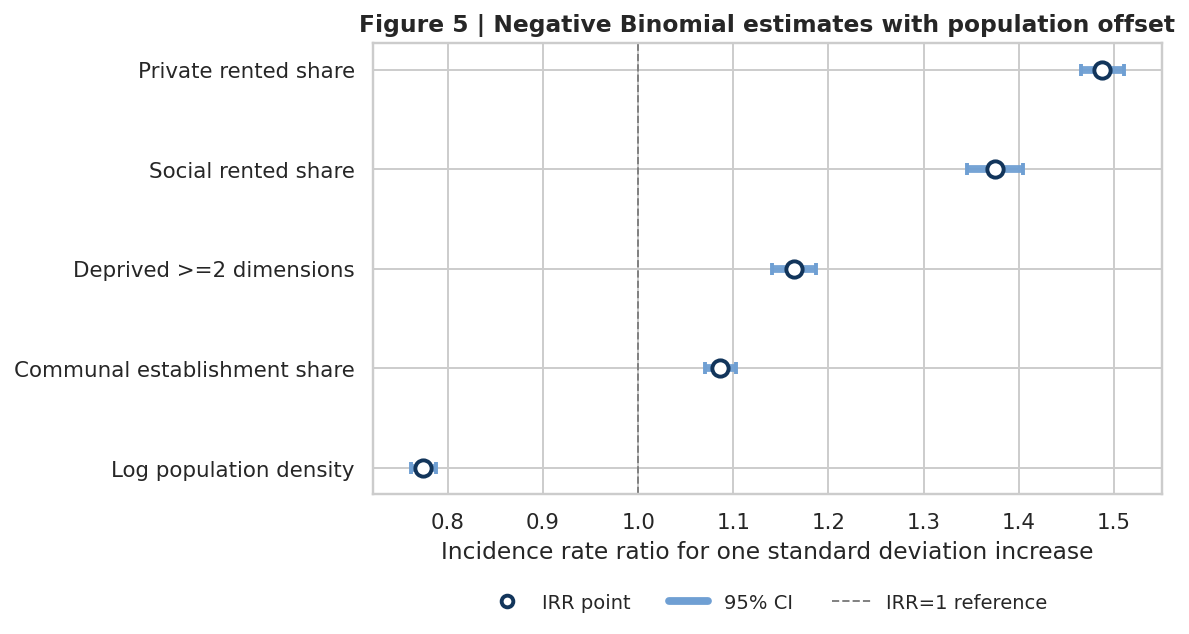

In [13]:
conf = nb_res.conf_int()
coef = pd.DataFrame({
    "term": nb_res.params.index,
    "coef": nb_res.params.values,
    "pvalue": nb_res.pvalues.values,
    "ci_low": conf[0].values,
    "ci_high": conf[1].values,
})
coef = coef[~coef["term"].isin(["const", "alpha"])].copy()
coef["irr"] = np.exp(coef["coef"])
coef["irr_low"] = np.exp(coef["ci_low"])
coef["irr_high"] = np.exp(coef["ci_high"])
coef["label"] = coef["term"].map(label_map)
coef.to_csv(OUT / "negative_binomial_coefficients.csv", index=False)
display(coef[["label", "irr", "irr_low", "irr_high", "pvalue"]].round(3))

coef_plot = coef.sort_values("irr")
fig, ax = plt.subplots(figsize=(8.8, 5.2))
ypos = np.arange(len(coef_plot))

# Draw confidence intervals explicitly so they remain visible in the report PDF.
ax.hlines(
    y=ypos,
    xmin=coef_plot["irr_low"],
    xmax=coef_plot["irr_high"],
    color="#6F9FD3",
    linewidth=4,
    alpha=0.95,
    zorder=1,
)
ax.vlines(coef_plot["irr_low"], ypos - 0.06, ypos + 0.06, color="#6F9FD3", linewidth=2, zorder=1)
ax.vlines(coef_plot["irr_high"], ypos - 0.06, ypos + 0.06, color="#6F9FD3", linewidth=2, zorder=1)
ax.scatter(
    coef_plot["irr"],
    ypos,
    s=70,
    facecolor="white",
    edgecolor="#12355B",
    linewidth=2,
    zorder=3,
)
ax.axvline(1, color="grey", linestyle="--", lw=1)
ax.set_yticks(ypos)
ax.set_yticklabels(coef_plot["label"])
ax.set_xlabel("Incidence rate ratio for one standard deviation increase")
ax.set_title("Figure 5 | Negative Binomial estimates with population offset", weight="bold")
from matplotlib.lines import Line2D

ax.legend(
    handles=[
        Line2D([0], [0], marker="o", markerfacecolor="white", markeredgecolor="#12355B", markeredgewidth=2, color="none", linestyle="", label="IRR point"),
        Line2D([0], [0], color="#6F9FD3", lw=4, label="95% CI"),
        Line2D([0], [0], color="grey", lw=1, linestyle="--", label="IRR=1 reference"),
    ],
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=3,
    fontsize=10,
)
ax.set_xlim(coef_plot["irr_low"].min() - 0.04, coef_plot["irr_high"].max() + 0.04)
fig.subplots_adjust(left=0.34, right=0.98, top=0.86, bottom=0.24)
fig.savefig(OUT / "fig_04_negative_binomial_irr.png", dpi=220, bbox_inches="tight")
plt.show()


**Figure 5 | Negative Binomial IRR estimates.** Points show incidence rate ratios for a one standard deviation predictor increase; horizontal bars are 95% confidence intervals. Intervals not crossing 1 indicate statistical significance. Because the sample is large, some confidence intervals are narrow, so substantive interpretation should consider effect size as well as p-values.


The Poisson overdispersion ratio is **37.49**, so Negative Binomial is used. All predictors are standardised. IRRs are about **1.49** for private rented share, **1.37** for social rented share and **1.16** for households deprived in two or more dimensions, meaning these variables are associated with higher expected recorded violence counts after the population offset. Communal-establishment share is also positive but smaller.

The negative density coefficient should not be interpreted as density reducing violence. It is more likely a conditional association after controlling for tenure and deprivation, and it may reflect the limitation of residential population as an exposure denominator in areas with high daytime, visitor, commuter or night-time activity. The model therefore identifies spatial association, not a behavioural mechanism.


In [14]:
# Robustness check: add borough fixed effects to partially account for administrative context.
borough_dummies = pd.get_dummies(analysis["borough_code"], prefix="borough", drop_first=True, dtype=float)
X_fe = pd.concat([X_scaled.reset_index(drop=True), borough_dummies.reset_index(drop=True)], axis=1)
X_fe = sm.add_constant(X_fe)

nb_fe = NegativeBinomial(y.reset_index(drop=True), X_fe, loglike_method="nb2", offset=offset.reset_index(drop=True))
nb_fe_res = nb_fe.fit(disp=False, maxiter=200)

fe_terms = [v + "_z" for v in model_vars]
robustness = pd.DataFrame({
    "label": [label_map[t] for t in fe_terms],
    "main_nb_irr": np.exp(nb_res.params[fe_terms]).values,
    "borough_fe_nb_irr": np.exp(nb_fe_res.params[fe_terms]).values,
    "borough_fe_pvalue": nb_fe_res.pvalues[fe_terms].values,
}).round(3)

robustness.to_csv(OUT / "negative_binomial_borough_fe_robustness.csv", index=False)
display(robustness)
print("Borough fixed-effects NB converged:", nb_fe_res.mle_retvals.get("converged"))


,label,main_nb_irr,borough_fe_nb_irr,borough_fe_pvalue
0,Deprived >=2 dimensions,1.164,1.164,0.0
1,Log population density,0.774,0.782,0.0
2,Social rented share,1.375,1.390,0.0
3,Private rented share,1.488,1.548,0.0
4,Communal establishment share,1.086,1.086,0.0


Borough fixed-effects NB converged: True


With borough fixed effects, core variable directions remain unchanged: private renting, social renting, household deprivation and communal-establishment share remain positive, while log density remains negative. This suggests the results are not only borough mean differences. However, this check cannot remove spatial dependence, unobserved activity exposure or policing/reporting variation. Future work could use spatial regression, smaller activity-space exposure measures or richer land-use controls.


In [15]:
cluster_features = [
    "violence_rate_per_1000_annual", "deprived_2plus_pct",
    "log_population_density", "social_rented_pct", "private_rented_pct"
]
Z = StandardScaler().fit_transform(analysis[cluster_features])
sil_scores = {}
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=30)
    labels = km.fit_predict(Z)
    sil_scores[k] = silhouette_score(Z, labels)

best_k = max(sil_scores, key=sil_scores.get)
print("Silhouette scores:", {k: round(v, 3) for k, v in sil_scores.items()})
print("Chosen k:", best_k)

km = KMeans(n_clusters=best_k, random_state=42, n_init=50)
analysis["cluster"] = km.fit_predict(Z)

cluster_profile = analysis.groupby("cluster")[cluster_features + ["population_2021"]].mean().round(2)
cluster_profile["lsoa_n"] = analysis["cluster"].value_counts().sort_index()
cluster_profile = cluster_profile.sort_values("violence_rate_per_1000_annual", ascending=False)
ordered_clusters = cluster_profile.index.tolist()
cluster_label_map = {old: f"C{i+1}" for i, old in enumerate(ordered_clusters)}
analysis["cluster_label"] = analysis["cluster"].map(cluster_label_map)

cluster_profile = analysis.groupby("cluster_label")[cluster_features + ["population_2021"]].mean().round(2)
cluster_profile["lsoa_n"] = analysis.groupby("cluster_label").size()
cluster_profile = cluster_profile.sort_index()
cluster_profile.to_csv(OUT / "cluster_profile.csv")
display(cluster_profile)


Silhouette scores: {2: 0.299, 3: 0.294, 4: 0.304, 5: 0.252, 6: 0.238}
Chosen k: 4


,violence_rate_per_1000_annual,deprived_2plus_pct,log_population_density,social_rented_pct,private_rented_pct,population_2021,lsoa_n
cluster_label,,,,,,,
C1,168.54,17.61,8.63,22.84,46.53,1753.68,79
C2,31.04,27.78,9.32,46.50,23.15,1802.15,1437
C3,25.31,17.15,9.35,15.84,41.21,1801.00,1903
C4,15.48,13.46,8.36,8.87,18.84,1679.84,1569


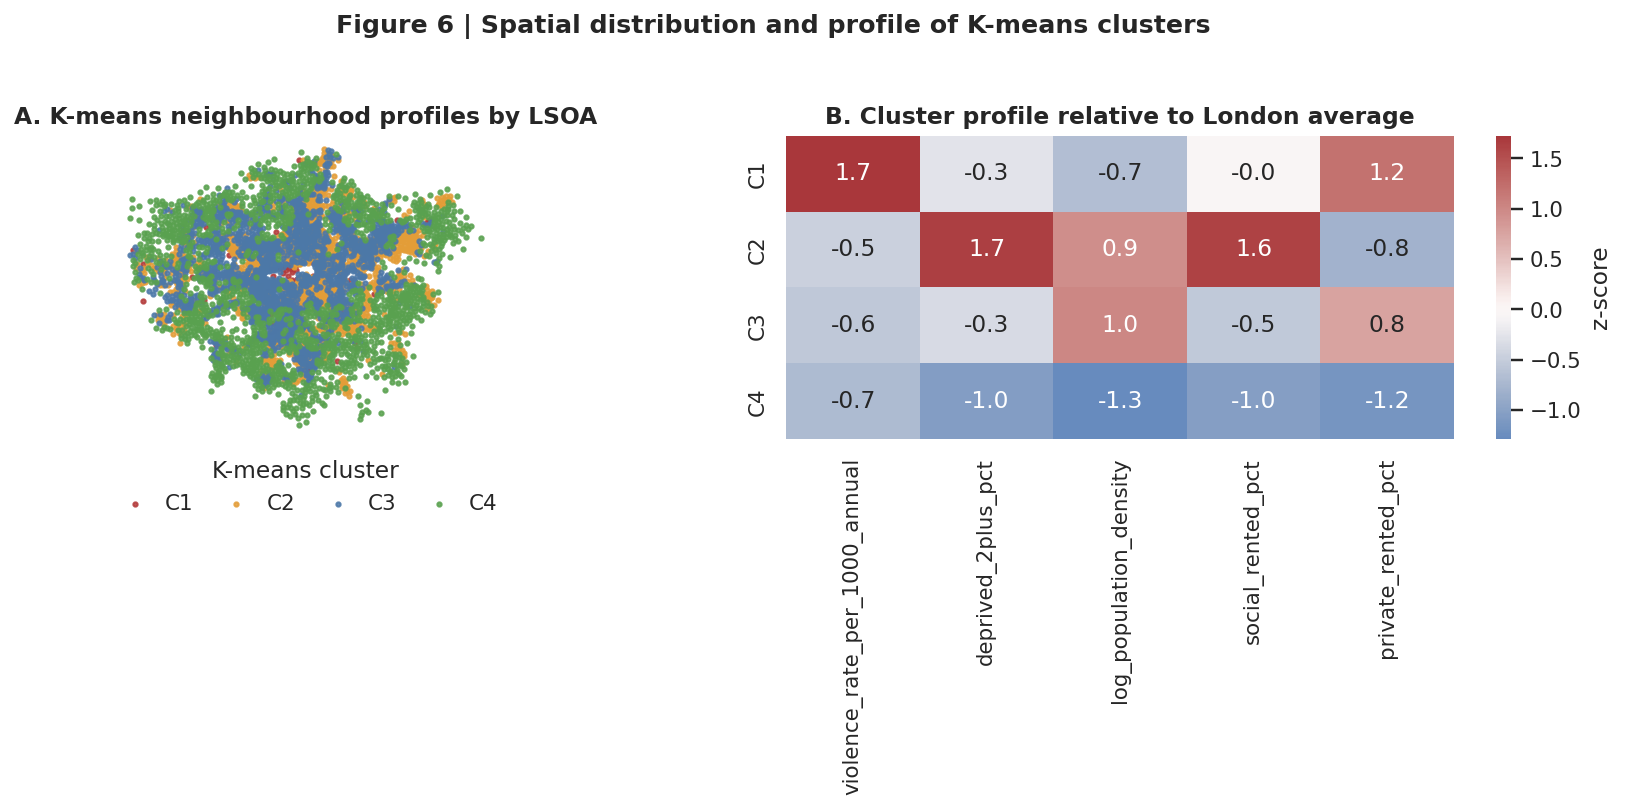

In [16]:
palette = {"C1": "#B33A3A", "C2": "#E39D38", "C3": "#4C78A8", "C4": "#59A14F", "C5": "#8E6BBE", "C6": "#777777"}
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for lab, sub in analysis.groupby("cluster_label"):
    axes[0].scatter(sub["bng_e"], sub["bng_n"], s=5, alpha=.85, label=lab, color=palette.get(lab))
axes[0].set_aspect("equal")
axes[0].set_axis_off()
axes[0].legend(
    frameon=False,
    title="K-means cluster",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.04),
    ncol=4,
    borderaxespad=0,
    handletextpad=0.4,
    columnspacing=1.0,
)
axes[0].set_title("A. K-means neighbourhood profiles by LSOA", weight="bold")

profile_norm = cluster_profile[cluster_features].copy()
profile_norm = (profile_norm - profile_norm.mean()) / profile_norm.std(ddof=0)
sns.heatmap(profile_norm, cmap="vlag", center=0, annot=True, fmt=".1f", cbar_kws={"label": "z-score"}, ax=axes[1])
axes[1].set_title("B. Cluster profile relative to London average", weight="bold")
axes[1].set_xlabel("")
axes[1].set_ylabel("")
fig.suptitle("Figure 6 | Spatial distribution and profile of K-means clusters", fontsize=13, weight="bold", y=1.02)
fig.tight_layout(rect=[0, 0.06, 1, 1])
fig.savefig(OUT / "fig_05_clusters.png")
plt.show()

analysis.to_csv(DATA / "processed_lsoa_analysis.csv", index=False)


**Figure 6 | Exploratory K-means neighbourhood profiles.** The map shows **4** LSOA profiles; the heatmap compares standardised cluster means for violence rate, deprivation, density and tenure. The figure should be read as a descriptive summary of neighbourhood profiles, not as a hard classification of community types.


K-means uses violence rate, deprivation, density and tenure variables. Silhouette scores for `k=2..6` select **4** clusters, but the score is moderate, so clusters are descriptive profiles rather than definitive categories. C1 contains a small high-rate, high-private-renting group; C2 is more deprived and socially rented; C4 is lower-rate, lower-deprivation and lower-renting. Clustering helps summarise spatial profiles but is not causal.


<a id="discussion"></a>

## 7.0 | Discussion and Conclusion

[[go back to the top]](#top)

**RQ1:** Recorded Violence Against the Person is spatially uneven across London 2021 LSOAs in 2024-2026. Central activity areas and some high-renting, high-mobility places have higher annualised rates. Westminster has the highest borough rate and Richmond upon Thames the lowest, but LSOA variation is more detailed than borough averages.

**RQ2:** After accounting for residential population, deprivation, social renting, private renting and communal-establishment population are associated with higher recorded violence counts. Poisson diagnostics show strong overdispersion, so Negative Binomial is more suitable than Poisson. The borough fixed-effects robustness check keeps the same core directions, which strengthens the interpretation that the associations are not only broad borough differences. The negative density coefficient is only a conditional association and may reflect tenure, central activity and poor measurement of daytime or night-time exposure.

**RQ3:** K-means identifies four exploratory LSOA profiles, including high-rate/private-renting, high-deprivation/social-renting and low-rate/low-deprivation profiles. Because silhouette performance is moderate, these are descriptive profiles rather than fixed neighbourhood classes.

This study explains spatial association rather than causality. Limitations include recorded crime bias, the time gap between 2021 Census covariates and the 2024-2026 crime window, area-level inference, MAUP sensitivity, and borough differences in administration, policing, reporting, night-time economy, transport hubs and central activity zones. Future work could add daytime population, land use, transport accessibility and spatial models to separate resident risk from activity-population exposure.


<a id="refs"></a>

## Bibliography

[[ go back to the top ]](#top)

Brantingham, P. J. and Brantingham, P. L. (1995). Criminality of place: Crime generators and crime attractors. *European Journal on Criminal Policy and Research*, 3, pp. 5-26.

Metropolitan Police Service. (2026). *MPS Recorded Crime: Geographic Breakdown*. London Datastore. Available at: https://data.london.gov.uk/dataset/mps-recorded-crime-geographic-breakdown-exy3m/

Nomis / Office for National Statistics. (2023). *Census 2021 bulk data: TS001, TS006, TS011 and TS054*. Available at: https://www.nomisweb.co.uk/census/2021/bulk

Office for National Statistics. (2024). *Lower layer Super Output Areas (December 2021) Boundaries EW BGC (V5)*. ONS Open Geography Portal. Available at: https://geoportal.statistics.gov.uk/

Openshaw, S. (1984). *The Modifiable Areal Unit Problem*. Norwich: Geo Books.

Sampson, R. J., Raudenbush, S. W. and Earls, F. (1997). Neighborhoods and violent crime: A multilevel study of collective efficacy. *Science*, 277(5328), pp. 918-924.

Shaw, C. R. and McKay, H. D. (1942). *Juvenile Delinquency and Urban Areas: A Study of Rates of Delinquents in Relation to Differential Characteristics of Local Communities in American Cities*. Chicago: University of Chicago Press.

Weisburd, D., Groff, E. R. and Yang, S. M. (2012). *The Criminology of Place: Street Segments and Our Understanding of the Crime Problem*. Oxford: Oxford University Press.


<a id="appendix"></a>

## Appendix

[[ go back to the top ]](#top)

Project files:

- `data/`: downloaded source data and `processed_lsoa_analysis.csv`
- `outputs/`: figures, model coefficients, borough summary and cluster profile
- `data_sources.json`: download links and file-size records